# Pipeline的内部

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier(
    [
        "I've been waiting for a HuggingFace course my whole life.",
        "I hate this so much!",
    ]
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598048329353333},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

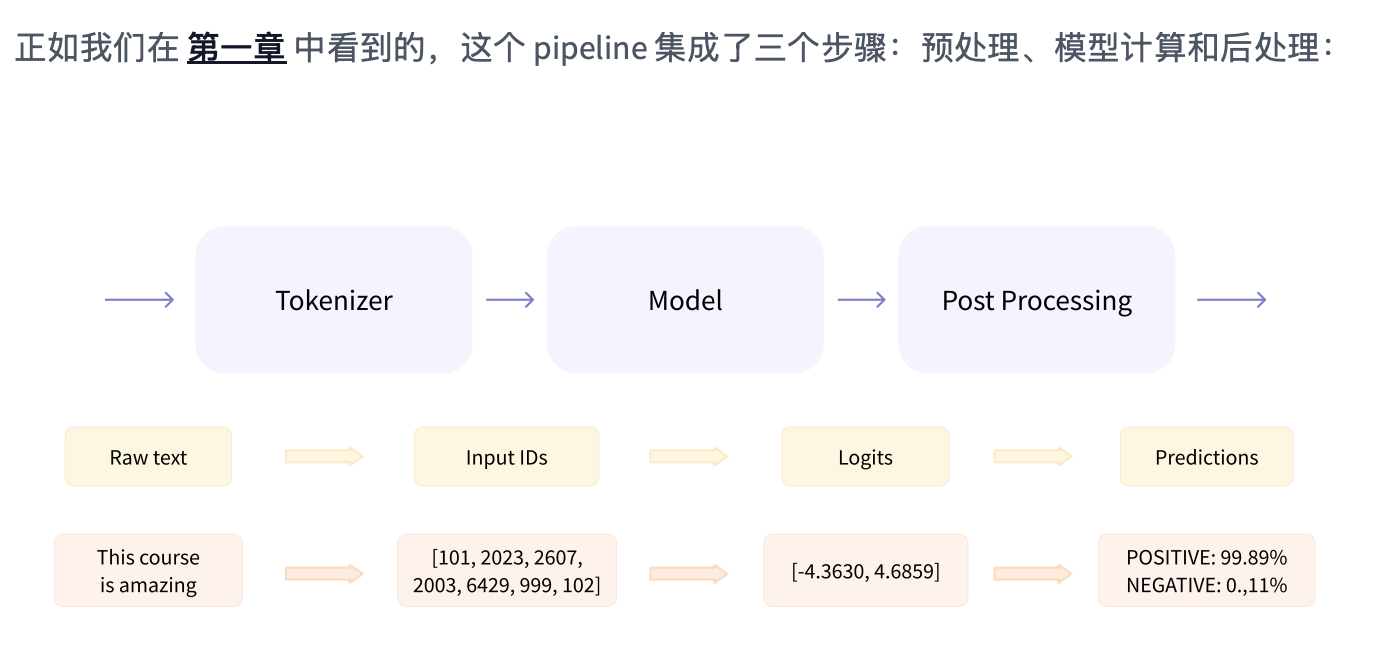

##使用 tokenizer进行预处理

与其他神经网络一样，Transformer 模型无法直接处理原始文本。
第一步是将文本输入转换为模型能够理解的数字。为此，我们使用 tokenizer：

*  将输入拆分为单词、子单词或符号（如标点符号），称为 token（标记）
*  将每个标记（token）映射到一个数字，称为 input ID（inputs ID）
*  添加模型需要的其他输入，例如特殊标记（如 [CLS] 和 [SEP] ）
*  位置编码：指示每个标记在句子中的位置。
*  段落标记：区分不同段落的文本。
*  特殊标记：例如 [CLS] 和 [SEP] 标记，用于标识句子的开头和结尾。

### checkpoint
1. **字面含义**：模型训练过程保存的**断点权重文件/预训练模型快照**，记录模型全部参数、分词器配置、标签映射等完整配套信息。

2. **核心价值**
    不用从零训练Transformer，直接加载成熟权重，配套tokenizer、模型头、标签映射一次性匹配，保证预处理+模型推理流程和预训练/微调时完全一致。


**使用模型时所有这些预处理都需要与模型预训练时的方式完全相同**，为此，我们使用 `AutoTokenizer` 类和它的 `from_pretrained()` 方法，并输入我们**模型 checkpoint 的名称**，它将自动获取与模型的 tokenizer 相关联的数据。

In [3]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

当我们有了 tokenizer，我们就可以直接将我们的句子传递给它，我们就会得到一个 **input ID 的列表**！剩下要做的唯一一件事就是**将 input ID 列表转换为 tensor（张量）**。

In [6]:
raw_inputs = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]
#使用 return_tensors 参数指定我们想要得到的 tensor 的类型（PyTorch、TensorFlow 或纯 NumPy）
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102],
        [  101,  1045,  5223,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


输出是一个包含两个键， `input_ids `和 `attention_mask `。 input_ids 包含两行整数（每个句子一行），它们是每个句子中 token 的 ID。

##探索模型

我们可以像使用 tokenizer 一样**下载预训练模型**。Transformers 提供了一个 `AutoModel` 类，它也有一个 `from_pretrained()` 方法：

In [7]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
#将之前在 pipeline 中使用的 checkpoint（已缓存）下载下来，并用它实例化了一个模型。
model = AutoModel.from_pretrained(checkpoint)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



这个模型只包含基本的 Transformer 模块：**输入一些句子，它输出我们将称为 hidden states（隐状态）** ，也被称为**特征**。每个输入，我们都可以获取一个**高维向量**，代表 Transformer 模型**对该输入的上下文理解。**

如果这有些难以理解，不要担心。我们以后再解释。

这些隐状态本身就很有用，它们被称为**模型头（head）**，通常是模型另一部分的输入。在 第一章 中，可以使用相同的体系结构的模型执行不同的任务，这是因为每个任务都有一个对应的模型头。

##高维向量？

Transformers 模块的**矢量输出**通常较大。它通常有三个维度：

*  Batch size（批次大小）：一次处理的序列数（在我们的示例中为 2）。
*  Sequence length（序列长度）：表示序列（句子）的长度（在我们的示例中为 16）。
*  Hidden size（隐藏层大小）：每个模型输入的向量维度。

之所以说它是“高维度”的，是因为最后一个维度值。隐藏层维度可以非常大（对于较小的模型，常见的是 768，对于较大的模型，这个数字可以达到 3072 或更多）。

如果我们将预处理的之后的值输入到模型中，我们会得到以下输入：

In [ ]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([2, 16, 768])

##Head 模型头：理解数字的意义

Transformers 模型的输出会直接发送到模型头进行处理。

模型头通常由一个或几个线性层组成，它的**输入是隐状态的高维向量**，**它会并将其投影到不同的维度**。

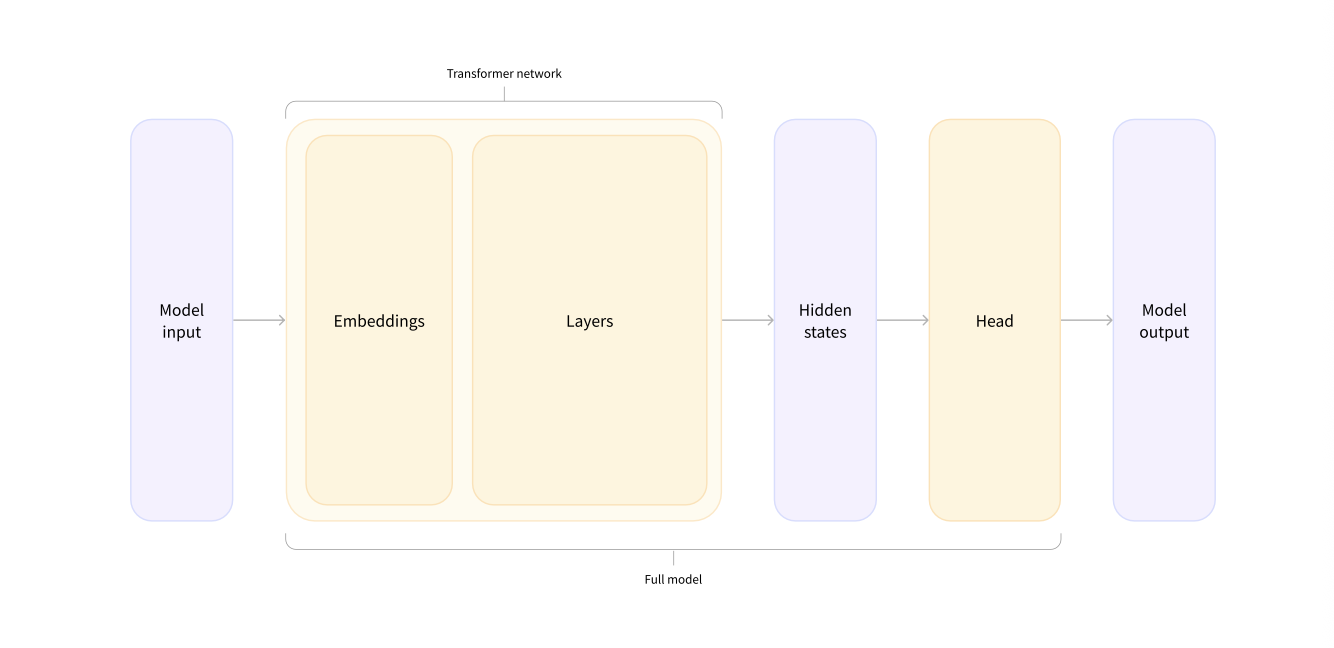

在此图中，模型由其嵌入层和后续层表示。嵌入层将 tokenize 后输入中的每个 inputs ID 转换为表示关联 token 的向量。后续层使用注意机制操纵这些向量，生成句子的最终表示。

Transformers 中有许多不同的体系结构，每种体系结构都是围绕处理特定任务而设计的。

以情感分类为例，我们需要一个带有序列分类头的模型（能够将句子分类为积极或消极）。因此，我们不选用 `AutoModel` 类，而是使用 `AutoModelForSequenceClassification` 。也就是说前面写的 `model = AutoModel.from_pretrained(checkpoint)` 并不能得到情感分类任务的结果，因为没有加载 Model head。 **AutoModelForSequenceClassification 类在 AutoModel 的基础上添加了一个序列分类 head **，可以 将文本分类为不同的类别。

In [ ]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

输出向量的尺寸与输入向量相比要小得多。这是因为模型头将输入向量中的信息压缩成两个值。

由于我们只有两个句子和两种标签，所以我们从模型中得到的结果的形状是 2 x 2。

In [ ]:
print(outputs.logits.shape)

torch.Size([2, 2])

## 对输出进行后处理

把模型看不懂的原始分值，转换成人类能直接解读的分类概率与标签。

In [ ]:
print(outputs.logits)

tensor([[-1.5607,  1.6123],
        [ 4.1692, -3.3464]], grad_fn=<AddmmBackward>)

这些不是概率，而是 `logits`（**对数几率**），是模型最后一层输出的原始的、未标准化的分数。要**转换为概率**，它们需要经过 **SoftMax** 层

In [ ]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[4.0195e-02, 9.5980e-01],
        [9.9946e-01, 5.4418e-04]], grad_fn=<SoftmaxBackward>)

这些是可直接使用的概率分数。

为了获得每个分数对应的标签，我们可以查看模型配置的 `id2label` 属性（下一节将对此进行详细介绍），该属性将每个模型输出的 ID 映射到相应的标签：

In [ ]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

我们已经成功地复刻了管道的三个步骤：使用 tokenizer 进行预处理、通过模型传递输入以及后处理！